In [21]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [22]:
class Node:
    def __init__(self, index, t, true_branch, false_branch):
        self.index = index
        self.t = t
        self.true_branch = true_branch
        self.false_branch = false_branch

In [23]:
class Leaf:
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        self.prediction = self.predict()
    
    def predict(self):
        unique_labels, counts = np.unique(self.labels, return_counts=True)
        return unique_labels[np.argmax(counts)]

In [24]:
class RandomForestClassifier:
    def __init__(self, n_trees=10, min_leaf=1, random_state=83):
        self.n_trees = n_trees
        self.min_leaf = min_leaf
        self.random_state = random_state
        self.trees = []
        self.feature_subsample_size = None
        np.random.seed(random_state)
        random.seed(random_state)
    
    def get_bootstrap(self, data, labels, N):
        n_samples = data.shape[0]
        bootstrap = []

        for _ in range(N):
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            b_data = data[indices]
            b_labels = labels[indices]
            bootstrap.append((b_data, b_labels))
        
        return bootstrap
    
    def get_subsample(self, len_sample):
        indices = list(range(len_sample))
        random.shuffle(indices)
        return indices[:self.feature_subsample_size]
    
    def gini(self, labels):
        _, counts = np.unique(labels, return_counts=True)
        probabilities = counts / len(labels)
        return 1 - np.sum(probabilities ** 2)
    
    def quality(self, left_labels, right_labels, current_gini):
        n_left = len(left_labels)
        n_right = len(right_labels)
        n_total = n_left + n_right
        
        gini_left = self.gini(left_labels)
        gini_right = self.gini(right_labels)

        weighted_gini = (n_left / n_total) * gini_left + (n_right / n_total) * gini_right
        return current_gini - weighted_gini
    
    def split(self, data, labels, index, t):
        mask = data[:, index] <= t
        return (
            data[mask],
            data[~mask],
            labels[mask],
            labels[~mask]
        )
    
    def find_best_split(self, data, labels):
        current_gini = self.gini(labels)
        best_gain = 0
        best_t = None
        best_index = None

        n_features = data.shape[1]
        feature_indices = self.get_subsample(n_features)

        for index in feature_indices:
            values = np.unique(data[:, index])

            for t in values[:-1]:
                _, _, true_labels, false_labels = self.split(data, labels, index, t)

                if (len(true_labels) < self.min_leaf) or (len(false_labels) < self.min_leaf):
                    continue
                
                gain = self.quality(true_labels, false_labels, current_gini)

                if gain > best_gain:
                    best_gain = gain
                    best_t = t
                    best_index = index
        
        if best_gain == 0:
            return None, None, None
        
        return best_gain, best_t, best_index
    
    def build_tree(self, data, labels):
        gain, t, index = self.find_best_split(data, labels)

        if gain is None:
            return Leaf(data, labels)
        
        true_data, false_data, true_labels, false_labels = self.split(data, labels, index, t)

        true_branch = self.build_tree(true_data, true_labels)
        false_branch = self.build_tree(false_data, false_labels)

        return Node(index, t, true_branch, false_branch)
    
    def classify_object(self, obj, node):
        if isinstance(node, Leaf):
            return node.prediction
        
        if obj[node.index] <= node.t:
            return self.classify_object(obj, node.true_branch)
        else:
            return self.classify_object(obj, node.false_branch)
    
    def predict_tree(self, data, tree_root):
        return np.array([self.classify_object(obj, tree_root) for obj in data])
    
    def fit(self, data, labels):
        self.feature_subsample_size = int(np.sqrt(data.shape[1]))

        bootstrap = self.get_bootstrap(data, labels, self.n_trees)

        self.trees = []
        for i in range(self.n_trees):
            X_boot, y_boot = bootstrap[i]
            tree_root = self.build_tree(X_boot, y_boot)
            self.trees.append(tree_root)
        
        return self
    
    def predict(self, data):
        predictions = np.zeros((data.shape[0], self.n_trees))

        for i, tree in enumerate(self.trees):
            predictions[:, i] = self.predict_tree(data, tree)

        voted_predictions = np.zeros(data.shape[0])
        for i in range(data.shape[0]):
            unique, counts = np.unique(predictions[i], return_counts=True)
            voted_predictions[i] = unique[np.argmax(counts)]
        
        return voted_predictions

In [25]:
def accuracy_metric(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [26]:
def get_meshgrid(data, step=0.05, border=1.2):
    x_min, x_max = data[:, 0].min() - border, data[:, 0].max() + border
    y_min, y_max = data[:, 1].min() - border, data[:, 1].max() + border
    return np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

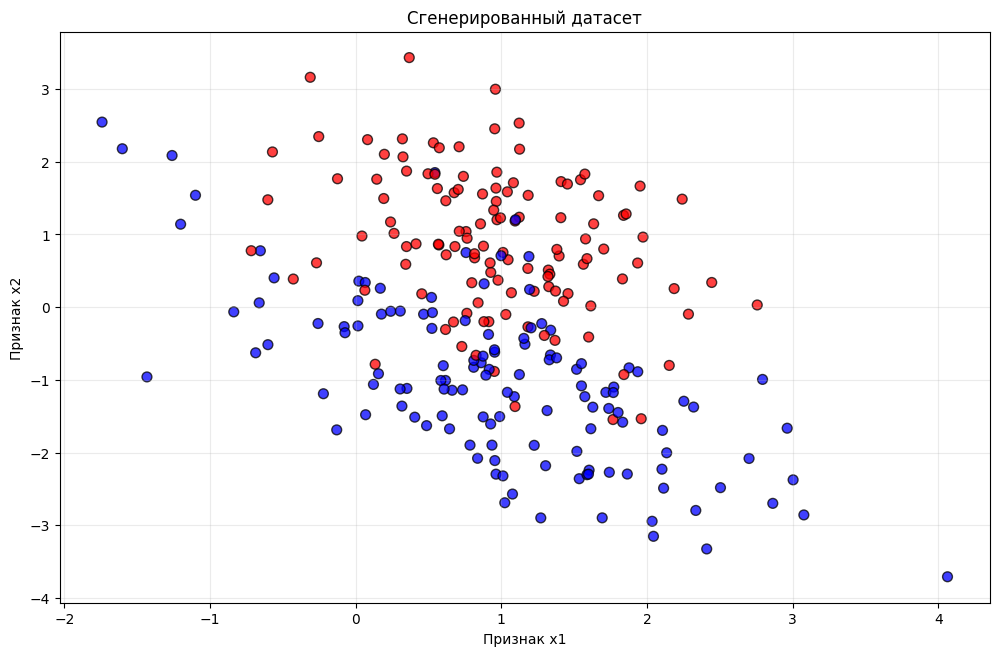

In [27]:
classification_data, classification_labels = datasets.make_classification(
    n_samples=250,
    n_features=2,
    n_informative=2,
    n_classes=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=1
)

colors = ListedColormap(["red", "blue"])
light_colors = ListedColormap(["lightcoral", "lightblue"])

plt.figure(figsize=(12, 12/1.618))
plt.scatter(classification_data[:, 0], classification_data[:, 1],
            c=classification_labels, cmap=colors, edgecolors="k", alpha=0.75, s=50)
plt.title("Сгенерированный датасет")
plt.xlabel("Признак x1")
plt.ylabel("Признак x2")
plt.grid(True, alpha=0.25)
plt.show()

In [28]:
train_data, test_data, train_labels, test_labels = train_test_split(
    classification_data, classification_labels, train_size=0.7, random_state=83
)

Точность леса из 1 дерева на обучающей выборке: 0.931
Точность леса из 1 дерева на тестовой выборке: 0.773


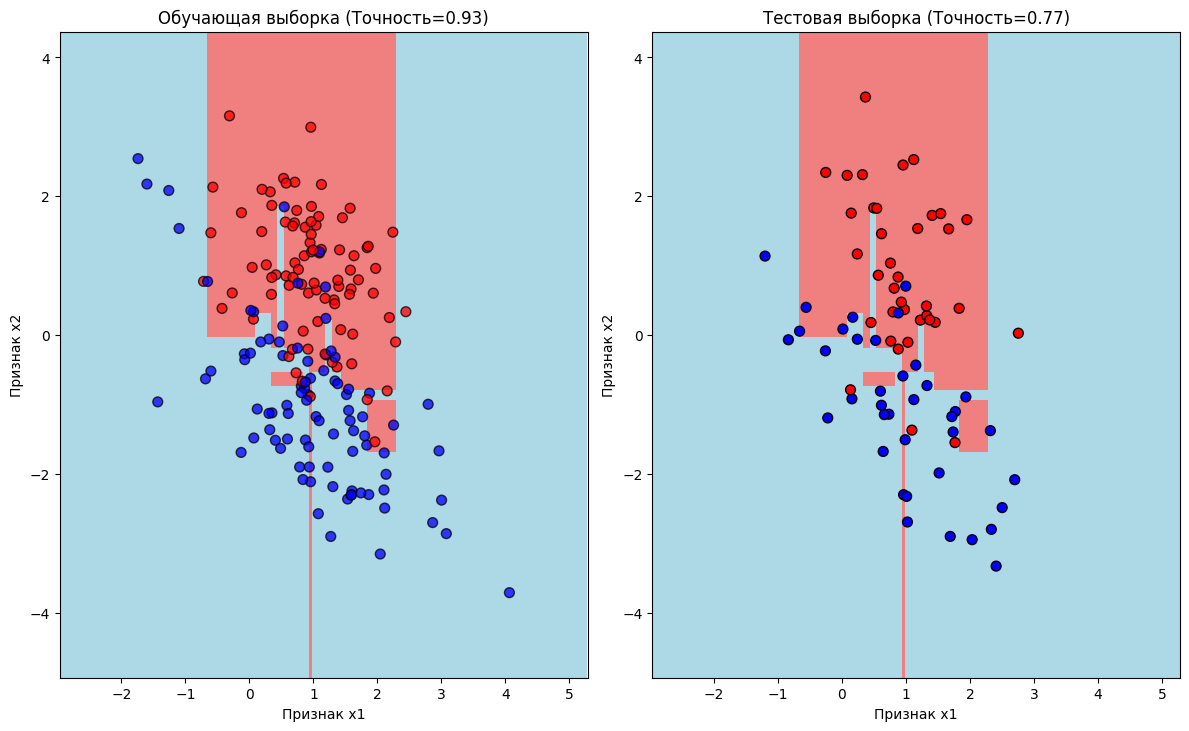

In [29]:
n_trees = 1
rf_1 = RandomForestClassifier(n_trees=n_trees, min_leaf=1, random_state=83)
rf_1.fit(train_data, train_labels)

train_pred_1 = rf_1.predict(train_data)
test_pred_1 = rf_1.predict(test_data)

train_acc_1 = accuracy_metric(train_labels, train_pred_1)
test_acc_1 = accuracy_metric(test_labels, test_pred_1)

print(f"Точность леса из {n_trees} дерева на обучающей выборке: {train_acc_1:.3f}")
print(f"Точность леса из {n_trees} дерева на тестовой выборке: {test_acc_1:.3f}")

xx, yy = get_meshgrid(train_data)
mesh_data = np.c_[xx.ravel(), yy.ravel()]

mesh_pred_1 = rf_1.predict(mesh_data).reshape(xx.shape)

plt.figure(figsize=(12, 12/1.618))

plt.subplot(1, 2, 1)
plt.pcolormesh(xx, yy, mesh_pred_1, cmap=light_colors)
plt.scatter(train_data[:, 0], train_data[:, 1], 
            c=train_labels, cmap=colors, edgecolors='k', s=50, alpha=0.75)
plt.title(f'Обучающая выборка (Точность={train_acc_1:.2f})')
plt.xlabel('Признак x1')
plt.ylabel('Признак x2')

plt.subplot(1, 2, 2)
plt.pcolormesh(xx, yy, mesh_pred_1, cmap=light_colors)
plt.scatter(test_data[:, 0], test_data[:, 1], 
            c=test_labels, cmap=colors, edgecolors='k', s=50)
plt.title(f'Тестовая выборка (Точность={test_acc_1:.2f})')
plt.xlabel('Признак x1')
plt.ylabel('Признак x2')

plt.tight_layout()
plt.show()


Точность леса из 100 деревьев на обучающей выборке: 1.000
Точность леса из 100 деревьев на тестовой выборке: 0.867


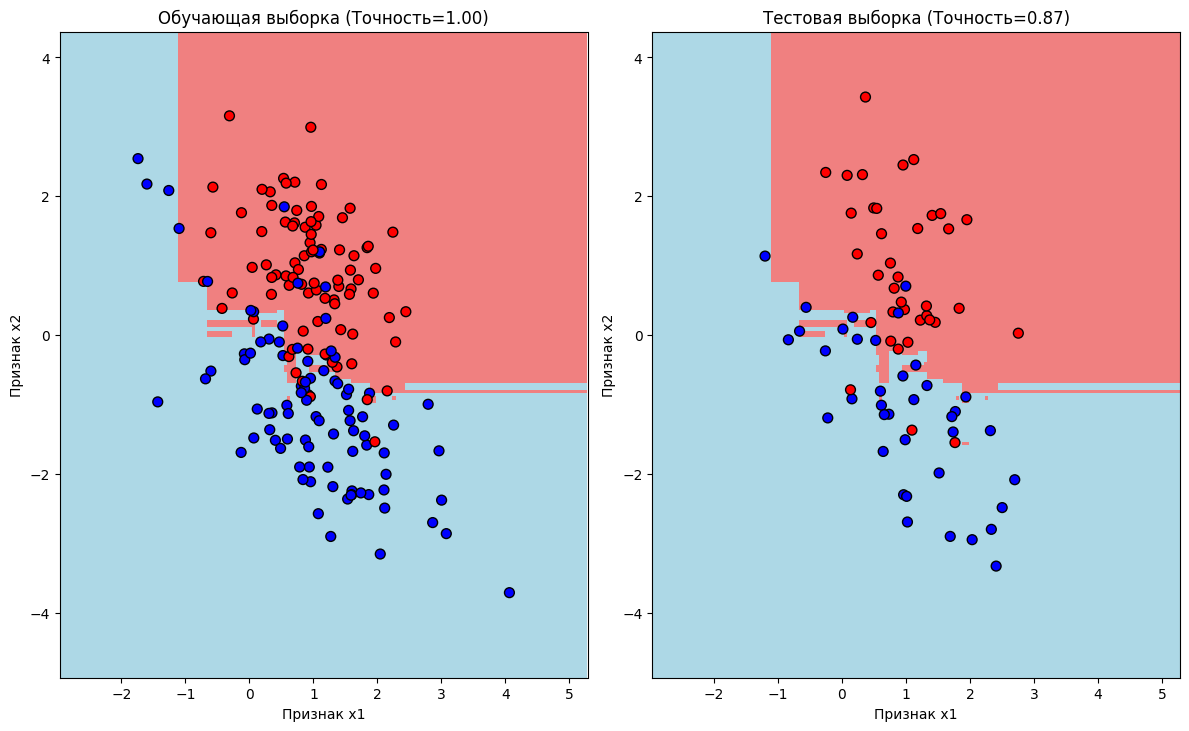

In [31]:
n_trees = 100
rf_10 = RandomForestClassifier(n_trees=n_trees, min_leaf=1, random_state=83)
rf_10.fit(train_data, train_labels)

train_pred_10 = rf_10.predict(train_data)
test_pred_10 = rf_10.predict(test_data)

train_acc_10 = accuracy_metric(train_labels, train_pred_10)
test_acc_10 = accuracy_metric(test_labels, test_pred_10)

print(f"\nТочность леса из {n_trees} деревьев на обучающей выборке: {train_acc_10:.3f}")
print(f"Точность леса из {n_trees} деревьев на тестовой выборке: {test_acc_10:.3f}")

mesh_pred_10 = rf_10.predict(mesh_data).reshape(xx.shape)

plt.figure(figsize=(12, 12/1.618))

plt.subplot(1, 2, 1)
plt.pcolormesh(xx, yy, mesh_pred_10, cmap=light_colors)
plt.scatter(train_data[:, 0], train_data[:, 1], 
            c=train_labels, cmap=colors, edgecolors='k', s=50)
plt.title(f'Обучающая выборка (Точность={train_acc_10:.2f})')
plt.xlabel('Признак x1')
plt.ylabel('Признак x2')

plt.subplot(1, 2, 2)
plt.pcolormesh(xx, yy, mesh_pred_10, cmap=light_colors)
plt.scatter(test_data[:, 0], test_data[:, 1], 
            c=test_labels, cmap=colors, edgecolors='k', s=50)
plt.title(f'Тестовая выборка (Точность={test_acc_10:.2f})')
plt.xlabel('Признак x1')
plt.ylabel('Признак x2')

plt.tight_layout()
plt.show()